# **Load the messy data**

In [3]:
import pandas as pd
import numpy as np

# Load the messy data
df = pd.read_csv('marketing_campaign_data_messy.csv')

print(f"Loaded Dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded Dataset: 2020 rows, 12 columns


In [4]:
df

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA
...,...,...,...,...,...,...,...,...,...,...,...,...
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,$503.95,77.0,1,NaN,TI
2016,CMP-01255,Q4_Summer_CMP-01255,2023-09-01 00:00:00,2023-09-26,Google Ads,20097,897,1641.0,162.0,0,NaN,GO
2017,CMP-01050,Q2_Launch_CMP-01050,2023-02-09 00:00:00,2023-02-21,Instagram,33254,1117,883.82,214.0,0,NaN,IN
2018,CMP-01118,Q4_Winter_CMP-01118,2023-03-30 00:00:00,2023-04-27,Facebook,68728,2960,4198.5,591.0,Yes,NaN,FA


## STEP 1: HEADER CLEANING

In [5]:
# ==========================================
# STEP 1: HEADER CLEANING
# ==========================================

print(df.columns.tolist())

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("\nFIX APPLIED\n")
print(df.columns.tolist())

[' Campaign_ID ', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel', 'Impressions', 'Clicks ', 'Spend', 'Conversions', 'Active', 'Clicks', 'Campaign_Tag']

FIX APPLIED

['campaign_id', 'campaign_name', 'start_date', 'end_date', 'channel', 'impressions', 'clicks', 'spend', 'conversions', 'active', 'clicks', 'campaign_tag']


## STEP 2: TYPE CONVERSION & CURRENCY CLEANING

In [6]:
# ==========================================
# STEP 2: TYPE CONVERSION & CURRENCY CLEANING
# ==========================================

dirty_spend_mask = df['spend'].astype(str).str.contains(r'\$')
print(df.loc[dirty_spend_mask, ['campaign_id','spend']].head(3))

df['spend'] = df['spend'].astype(str).str.replace(r'[^\d.-]','', regex=True)
df['spend'] = pd.to_numeric(df['spend'])

print("\nFIX APPLIED\n")
print(df.loc[dirty_spend_mask, ['campaign_id','spend']].head(3))

   campaign_id     spend
0    CMP-00001   $102.82
21   CMP-00022   $2428.4
22   CMP-00023  $4726.22

FIX APPLIED

   campaign_id    spend
0    CMP-00001   102.82
21   CMP-00022  2428.40
22   CMP-00023  4726.22


## STEP 3: CATEGORICAL TYPOS (FUZZY LOGIC)

In [7]:
# ==========================================
# STEP 3: CATEGORICAL TYPOS (FUZZY LOGIC)
# ==========================================

print(df['channel'].unique())

cleanup_map = {
    'Facebok' : 'Facebook',
    'Insta_gram' : 'Instagram',
    'Gogle' : 'Google Ads',
    'Tik_Tok' : 'TikTok',
    'E-mail' : 'Email',
    'N/A' : np.nan # Handling the ghost value here too
}

df['channel'] = df['channel'].replace(cleanup_map)
print("\nFIX APPLIED\n")
print(df['channel'].unique())

['TikTok' 'Facebook' 'Email' 'Instagram' 'Google Ads' 'E-mail' nan 'Gogle'
 'Tik_Tok' 'Facebok' 'Insta_gram']

FIX APPLIED

['TikTok' 'Facebook' 'Email' 'Instagram' 'Google Ads' nan]


## STEP 4: HANDLING MIXED BOOLEANS

In [8]:
# ==========================================
# STEP 4: HANDLING MIXED BOOLEANS
# ==========================================

print(df['active'].unique())

bool_map = {
    'Yes': True,
    'Y' : True,
    '1' : True,
    'True' : True,
    'T' : True,
    'TRUE' : True,
    1 : True,
    'No' : False,
    'N' : False,
    '0' : False,
    0 : False,
    'False' : False,
    'F' : False,
    'FALSE' : False
}

df['active'] = df['active'].map(bool_map).fillna(False).astype(bool)
print("\nFIX APPLIED\n")
print(df['active'].unique())

['Y' '0' 'No' 'True' 'Yes' '1' 'False']

FIX APPLIED

[ True False]


## STEP 5: DATE PARSING

In [9]:
# ==========================================
# STEP 5: DATE PARSING
# ==========================================

print(df['start_date'].dtype)

df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], dayfirst=True, errors='coerce')

print("\nFIX APPLIED\n")
print(df['start_date'].dtype)

object

FIX APPLIED

datetime64[ns]


/var/folders/kw/3b0lr0pj3mz1p6p7lll999d80000gn/T/ipykernel_39311/498076149.py:8: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['end_date'] = pd.to_datetime(df['end_date'], dayfirst=True, errors='coerce')


In [10]:
# When performing STEP 6, we realize that there are two 'clicks' columns so we merge them using the code below
df = df.loc[:, ~df.columns.duplicated()]

In [11]:
df

,campaign_id,campaign_name,start_date,end_date,channel,impressions,clicks,spend,conversions,active,campaign_tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,102.82,20.0,True,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,False,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,False,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,NaT,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,Facebook,7265,169,252.44,30.0,True,FA
...,...,...,...,...,...,...,...,...,...,...,...
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31,2023-11-13,TikTok,30592,586,503.95,77.0,True,TI
2016,CMP-01255,Q4_Summer_CMP-01255,2023-09-01,2023-09-26,Google Ads,20097,897,1641.00,162.0,False,GO
2017,CMP-01050,Q2_Launch_CMP-01050,2023-02-09,2023-02-21,Instagram,33254,1117,883.82,214.0,False,IN
2018,CMP-01118,Q4_Winter_CMP-01118,2023-03-30,2023-04-27,Facebook,68728,2960,4198.50,591.0,True,FA


## STEP 6: LOGICAL INTEGRITY (CLICKS vs IMPRESSIONS)

In [12]:
# ==========================================
# STEP 5: LOGICAL INTEGRITY (CLICKS vs IMPRESSIONS)
# ==========================================

impossible_mask = df['clicks'] > df['impressions']

# Since impressions = no. of clickable items in a campaign, and clicks = clicks on the campaign, therefore no. of clicks should not be greater than no. of impressions
print(df.loc[impossible_mask, ['campaign_id', 'impressions', 'clicks']].head(3))


Empty DataFrame
Columns: [campaign_id, impressions, clicks]
Index: []


## STEP 7: LOGICAL INTEGRITY (TIME TRAVEL)

In [13]:
# ==========================================
# STEP 7: LOGICAL INTEGRITY (TIME TRAVEL)
# ==========================================

time_travel_mask = df['end_date'] < df['start_date']

print(df.loc[time_travel_mask, ['campaign_id', 'start_date', 'end_date']].head(3))
# Since majority of the campaigns last 30 days so we increase
df.loc[time_travel_mask, 'end_date'] = df.loc[time_travel_mask, 'start_date'] + pd.Timedelta(days=30)

print("\n FIX APPLIED \n")
print(df.loc[time_travel_mask, ['campaign_id','start_date','end_date']].head(3))

   campaign_id start_date   end_date
23   CMP-00024 2023-05-06 2023-05-01
54   CMP-00055 2023-09-01 2023-08-27
71   CMP-00072 2023-02-01 2023-01-27

 FIX APPLIED 

   campaign_id start_date   end_date
23   CMP-00024 2023-05-06 2023-06-05
54   CMP-00055 2023-09-01 2023-10-01
71   CMP-00072 2023-02-01 2023-03-03


## STEP 8: HANDLING OUTLIERS (WINSORIZING)

In [14]:
# ==========================================
# STEP 8: HANDLING OUTLIERS (WINSORIZING)
# ==========================================

Q1 = df['spend'].quantile(0.25)
Q3 = df['spend'].quantile(0.75)

IQR = Q3 - Q1
upper_limit = Q3 + (3* IQR)

outlier_mask = df['spend'] > upper_limit
print(df.loc[outlier_mask, ['campaign_id', 'spend']].head(3))

print("\n FIX APPLIED \n")

df.loc[outlier_mask, 'spend'] = upper_limit
print(df.loc[outlier_mask, ['campaign_id', 'spend']].head(3))

     campaign_id      spend
789    CMP-00790  500000.00
1443   CMP-01444    8921.51
1460   CMP-01461  500000.00

 FIX APPLIED 

     campaign_id      spend
789    CMP-00790  8603.5375
1443   CMP-01444  8603.5375
1460   CMP-01461  8603.5375


## STEP 9: STRING PARSING (FEATURE EXTRACTION)

In [15]:
# ==========================================
# STEP 9: STRING PARSING (FEATURE EXTRACTION)
# ==========================================

print(df['campaign_name'].head(3))

df['season'] = df['campaign_name'].str.extract(r'Q\d_([^_]+)_') # Extracts the value between the first and the second underscore in 'campaign_name'

print("\n FIX APPLIED \n")
print(df[['campaign_name', 'season']].head(3))

0    Q4_Summer_CMP-00001
1    Q1_Launch_CMP-00002
2    Q3_Winter_CMP-00003
Name: campaign_name, dtype: object

 FIX APPLIED 

         campaign_name  season
0  Q4_Summer_CMP-00001  Summer
1  Q1_Launch_CMP-00002  Launch
2  Q3_Winter_CMP-00003  Winter


In [16]:
df

,campaign_id,campaign_name,start_date,end_date,channel,impressions,clicks,spend,conversions,active,campaign_tag,season
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,102.82,20.0,True,TI,Summer
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,False,FA,Launch
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,False,EM,Winter
3,CMP-00004,Q1_BlackFriday_CMP-00004,NaT,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,TI,BlackFriday
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,Facebook,7265,169,252.44,30.0,True,FA,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31,2023-11-13,TikTok,30592,586,503.95,77.0,True,TI,Summer
2016,CMP-01255,Q4_Summer_CMP-01255,2023-09-01,2023-09-26,Google Ads,20097,897,1641.00,162.0,False,GO,Summer
2017,CMP-01050,Q2_Launch_CMP-01050,2023-02-09,2023-02-21,Instagram,33254,1117,883.82,214.0,False,IN,Launch
2018,CMP-01118,Q4_Winter_CMP-01118,2023-03-30,2023-04-27,Facebook,68728,2960,4198.50,591.0,True,FA,Winter


# EDA: EXPLORATORY DATA ANALYSIS

## STEP 1: BASIC OVERVIEW

In [17]:
# ==========================================
# EDA STEP 1: BASIC OVERVIEW
# ==========================================

print("=== Basic Shape ===")
print(df.shape)

print("\n=== Basic Info ===")
print(df.info())

print("\n=== Summary Statistics ===")
df[['impressions','clicks','spend','conversions']].describe().round(2)

=== Basic Shape ===
(2020, 12)

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   campaign_id    2020 non-null   object        
 1   campaign_name  2020 non-null   object        
 2   start_date     1687 non-null   datetime64[ns]
 3   end_date       2020 non-null   datetime64[ns]
 4   channel        1919 non-null   object        
 5   impressions    2020 non-null   int64         
 6   clicks         2020 non-null   int64         
 7   spend          2020 non-null   float64       
 8   conversions    1820 non-null   float64       
 9   active         2020 non-null   bool          
 10  campaign_tag   2020 non-null   object        
 11  season         2020 non-null   object        
dtypes: bool(1), datetime64[ns](2), float64(2), int64(2), object(5)
memory usage: 175.7+ KB
None

=== Summary Statistics ===


,impressions,clicks,spend,conversions
count,2020.00,2020.00,2020.00,1820.00
mean,49839.90,1500.74,1878.36,186.09
std,28579.64,1084.77,1643.70,160.13
min,1055.00,11.00,-2503.31,0.00
25%,25033.50,650.75,650.00,68.00
50%,50097.50,1245.00,1427.10,142.00
75%,74784.25,2185.25,2638.38,257.00
max,99875.00,4812.00,8603.54,943.00


## STEP 2: DERIVED METRICS

In [21]:
# ==========================================
# EDA STEP 2: DERIVED METRICS
# ==========================================

df['conversions'] = pd.to_numeric(df['conversions'], errors='coerce')
df['spend']       = pd.to_numeric(df['spend'], errors='coerce')
df['clicks']      = pd.to_numeric(df['clicks'], errors='coerce')
df['impressions'] = pd.to_numeric(df['impressions'], errors='coerce')

df['ctr'] = (df['clicks'] / df['impressions'] * 100).round(2) # Click-through rate %
df['cpc'] = (df['spend'] / df['impressions']).round(2) # Cost per click
df['cpa'] = (df['spend'] / df['conversions'].where(df['conversions'] > 0)).round(2) # Cost per acquisition
df['roi'] = (df['conversions'] / df['spend'] * 100).round(2) # Conversions per $100 spent
df['duration'] = (df['end_date'] - df['start_date']).dt.days

print("New columns added")
df[['campaign_id','ctr','cpc','cpa','roi','duration']].head(2)

New columns added


,campaign_id,ctr,cpc,cpa,roi,duration
0,CMP-00001,1.17,0.01,5.14,19.45,19.0
1,CMP-00002,1.61,0.01,24.33,4.11,6.0


## STEP 3: SETTING UP PLOT STYLE

In [22]:
# ==========================================
# EDA STEP 3: SETTING UP PLOT STYLE
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

## STEP 4: CHART 1: SPEND BY CHANNEL (BAR CHART)

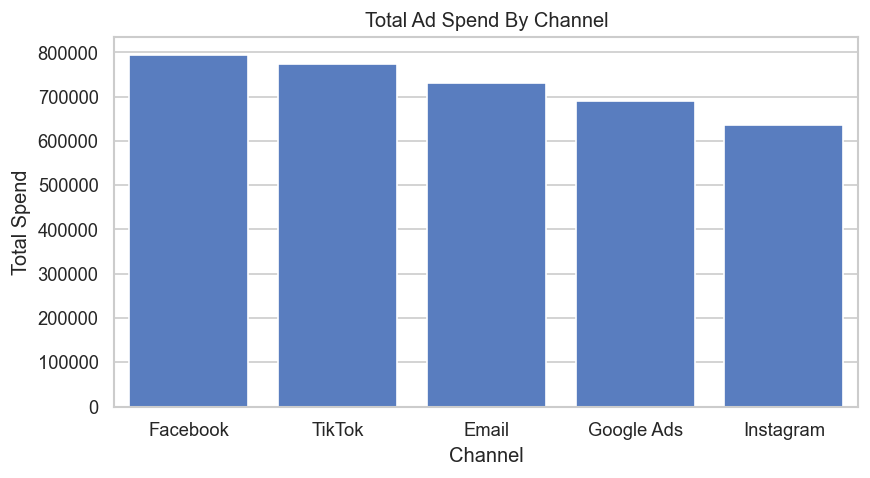

In [23]:
# ==========================================
# EDA STEP 4: CHART 1: SPEND BY CHANNEL (BAR CHART)
# ==========================================

channel_spend = df.groupby('channel')['spend'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=channel_spend, x='channel', y='spend')
plt.title('Total Ad Spend By Channel')
plt.xlabel('Channel')
plt.ylabel('Total Spend')
plt.show()

## STEP 5: CHART 2: SPEND VS CONVERSIONS BY CHANNEL

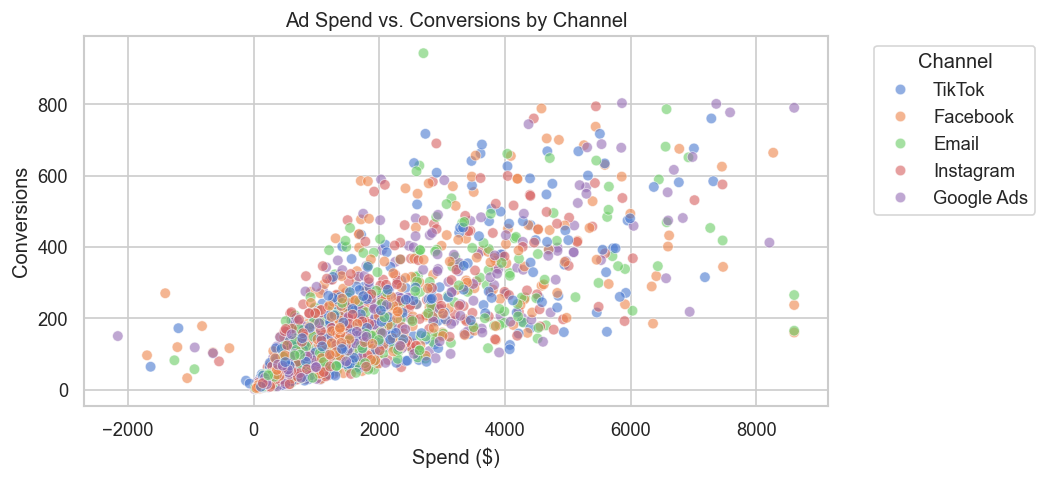

In [24]:
# ==========================================
# EDA TEP 5: CHART 2: SPEND VS CONVERSIONS BY CHANNEL
# ==========================================

plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='spend', y='conversions', hue='channel', alpha=0.6, s=40)
plt.title('Ad Spend vs. Conversions by Channel')
plt.xlabel('Spend ($)')
plt.ylabel('Conversions')
plt.legend(title='Channel',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## STEP 6: CHART 3: ROI BY SEASON

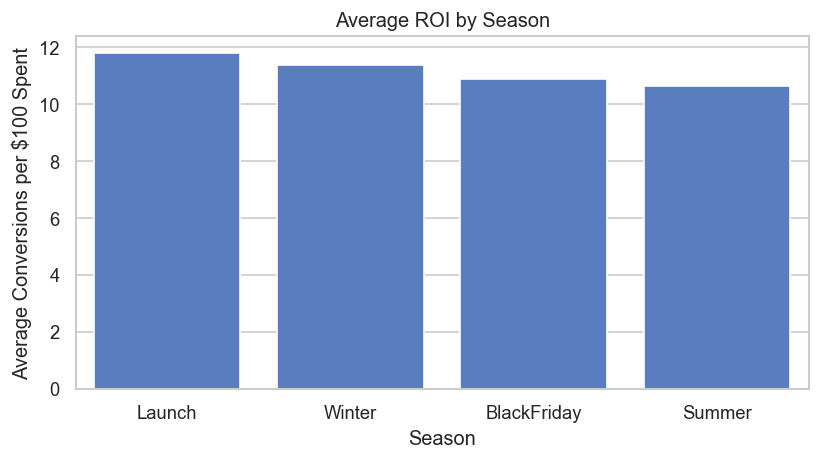

In [25]:
# ==========================================
# EDA STEP 6: CHART 3: ROI BY SEASON
# ==========================================

season_roi = df.groupby('season')['roi'].mean().reset_index().sort_values('roi',ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(data=season_roi, x='season', y='roi')
plt.title('Average ROI by Season')
plt.xlabel('Season')
plt.ylabel('Average Conversions per $100 Spent')
plt.tight_layout()
plt.show()

## STEP 7: CHART 4: CTR DISTRIBUTION BY CHANNEL

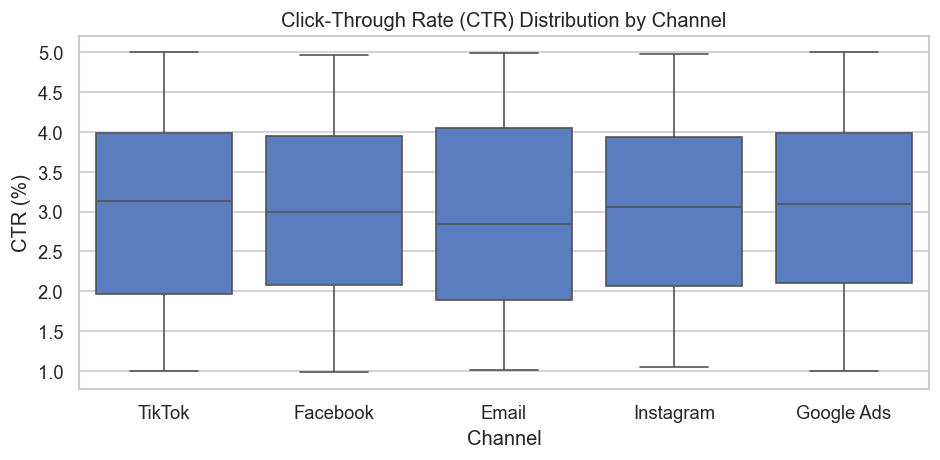

In [26]:
# ==========================================
# EDA STEP 7: CHART 4: CTR DISTRIBUTION BY CHANNEL
# ==========================================

plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='channel', y='ctr')
plt.title('Click-Through Rate (CTR) Distribution by Channel')
plt.xlabel('Channel')
plt.ylabel('CTR (%)')
plt.tight_layout()
plt.show()

## STEP 8: CHART 5: CORRELATION HEATMAP

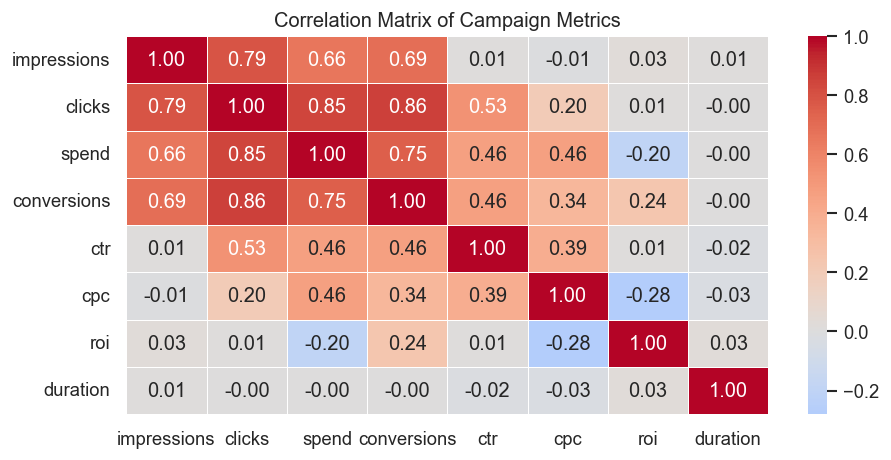

In [27]:
# ==========================================
# EDA STEP 8: CHART 5: CORRELATION HEATMAP
# ==========================================

numeric_cols = ['impressions','clicks','spend','conversions','ctr','cpc','roi','duration']
corr = df[numeric_cols].corr().round(2)

plt.figure(figsize=(8,4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix of Campaign Metrics')
plt.tight_layout()
plt.show()

# LOAD CLEANED DATA INTO SQL DATABASE

In [28]:
# ==========================================
# LOAD CLEANED DATA INTO SQL DATABASE
# ==========================================

import sqlite3

# Create a database file
conn = sqlite3.connect('marketing_campaigns.db')

# Write the cleaned dataframe into a SQL table
df.to_sql('campaigns', conn, if_exists='replace', index=False)

print("Data loaded into SQL successfully...")
print(f"Table 'campaigns' created with {len(df)} rows.")

Data loaded into SQL successfully...
Table 'campaigns' created with 2020 rows.


In [29]:
# Helper: run any SQL query and return a DataFrame
def query(sql):
  return pd.read_sql_query(sql, conn)

In [30]:
# ============================================
# QUERY 1: Performance summary by channel
# ============================================

query("""
    SELECT
        channel,
        COUNT(*)                          AS total_campaigns,
        ROUND(SUM(spend), 2)              AS total_spend,
        SUM(conversions)                  AS total_conversions,
        ROUND(AVG(ctr), 2)                AS avg_ctr,
        ROUND(SUM(conversions) * 100.0
              / SUM(spend), 2)            AS overall_roi
    FROM campaigns
    GROUP BY channel
    ORDER BY total_spend DESC
""")

,channel,total_campaigns,total_spend,total_conversions,avg_ctr,overall_roi
0,Facebook,405,795292.41,70563.0,3.03,8.87
1,TikTok,415,772722.11,68322.0,3.01,8.84
2,Email,380,730178.44,63378.0,2.93,8.68
3,Google Ads,360,690342.89,61332.0,3.02,8.88
4,Instagram,359,635718.76,57302.0,2.99,9.01
5,None,101,170031.95,17779.0,3.15,10.46


In [31]:
# ============================================
# QUERY 2: Top 10 most efficient campaigns
# ============================================

query("""
    SELECT
        campaign_id,
        campaign_name,
        channel,
        season,
        ROUND(spend, 2)       AS spend,
        conversions,
        ROUND(roi, 2)         AS roi
    FROM campaigns
    WHERE spend > 100
    ORDER BY roi DESC
    LIMIT 10
""")

,campaign_id,campaign_name,channel,season,spend,conversions,roi
0,CMP-01810,Q3_Launch_CMP-01810,Instagram,Launch,832.03,318.0,38.22
1,CMP-01306,Q1_BlackFriday_CMP-01306,Email,BlackFriday,509.23,192.0,37.70
2,CMP-00091,Q3_Launch_CMP-00091,Instagram,Launch,582.26,213.0,36.58
3,CMP-01930,Q3_BlackFriday_CMP-01930,Instagram,BlackFriday,601.28,217.0,36.09
4,CMP-00703,Q1_Summer_CMP-00703,Facebook,Summer,422.04,148.0,35.07
5,CMP-01624,Q3_BlackFriday_CMP-01624,Google Ads,BlackFriday,419.79,147.0,35.02
6,CMP-01621,Q2_Launch_CMP-01621,Email,Launch,2702.43,943.0,34.89
7,CMP-01001,Q2_Winter_CMP-01001,Facebook,Winter,312.14,108.0,34.60
8,CMP-00633,Q3_Winter_CMP-00633,Facebook,Winter,1704.64,585.0,34.32
9,CMP-01592,Q4_BlackFriday_CMP-01592,None,BlackFriday,324.19,110.0,33.93


In [32]:
# ============================================
# QUERY 3: Best channel per season
# ============================================

query("""
    SELECT
        season,
        channel,
        ROUND(AVG(roi), 2)        AS avg_roi,
        ROUND(AVG(ctr), 2)        AS avg_ctr,
        COUNT(*)                  AS total_campaigns
    FROM campaigns
    GROUP BY season, channel
    ORDER BY season, avg_roi DESC
""")

,season,channel,avg_roi,avg_ctr,total_campaigns
0,BlackFriday,None,11.85,3.23,23
1,BlackFriday,Google Ads,11.35,2.91,80
2,BlackFriday,Email,11.30,2.81,90
3,BlackFriday,TikTok,10.89,3.07,111
4,BlackFriday,Instagram,10.79,2.86,95
5,BlackFriday,Facebook,9.95,3.04,106
6,Launch,None,14.48,3.06,23
7,Launch,Instagram,13.04,3.08,93
8,Launch,Email,11.79,2.94,97
9,Launch,TikTok,11.69,2.98,107


In [33]:
# ============================================
# QUERY 4: Active vs inactive campaigns
# ============================================

query("""
    SELECT
        active,
        COUNT(*)                  AS total_campaigns,
        ROUND(AVG(spend), 2)      AS avg_spend,
        ROUND(AVG(conversions), 2)  AS avg_conversions,
        ROUND(AVG(roi), 2)        AS avg_roi
    FROM campaigns
    GROUP BY active
""")

,active,total_campaigns,avg_spend,avg_conversions,avg_roi
0,0,825,1907.01,184.86,11.21
1,1,1195,1858.58,186.93,11.13


# ML MODEL - PREDICT CONVERSIONS

In [34]:
# ============================================
# STEP 1: PREPARE THE FEATURES
# ============================================
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Select features and target
features = ['spend','impressions','duration','ctr','channel','season']
target = 'conversions'

ml_df = df[features + [target]].dropna()

# One-hot encode categorical columns (channel, season)
ml_df = pd.get_dummies(ml_df, columns=['channel', 'season'], drop_first=True)

print("Features ready:", ml_df.shape)
print(ml_df.head(3))

Features ready: (1433, 12)
     spend  impressions  duration   ctr  conversions  channel_Facebook  \
0   102.82        16795      19.0  1.17         20.0             False   
1    24.33         1860       6.0  1.61          1.0              True   
2  1323.39        77820       7.0  1.08         51.0             False   

   channel_Google Ads  channel_Instagram  channel_TikTok  season_Launch  \
0               False              False            True          False   
1               False              False           False           True   
2               False              False           False          False   

   season_Summer  season_Winter  
0           True          False  
1          False          False  
2          False           True  


In [35]:
# ============================================
# STEP 2: TRAIN THE MODEL
# ============================================

X = ml_df.drop(columns=[target])
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("Model trained!")

Training samples: 1146
Testing samples: 287
Model trained!


In [36]:
# ============================================
# STEP 3: MODEL EVALUATION
# ============================================

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f} conversions")

print()
if r2 > 0.7:
  print("Strong model - spend and impressions are good predictors of conversions.")
elif r2 > 0.4:
  print("Moderate model - some signal, but conversions on other factors too.")
else:
  print("Weak model - conversions are hard to predict from these features alone.")

R-squared: 0.70
Mean Absolute Error: 66.64 conversions

Moderate model - some signal, but conversions on other factors too.


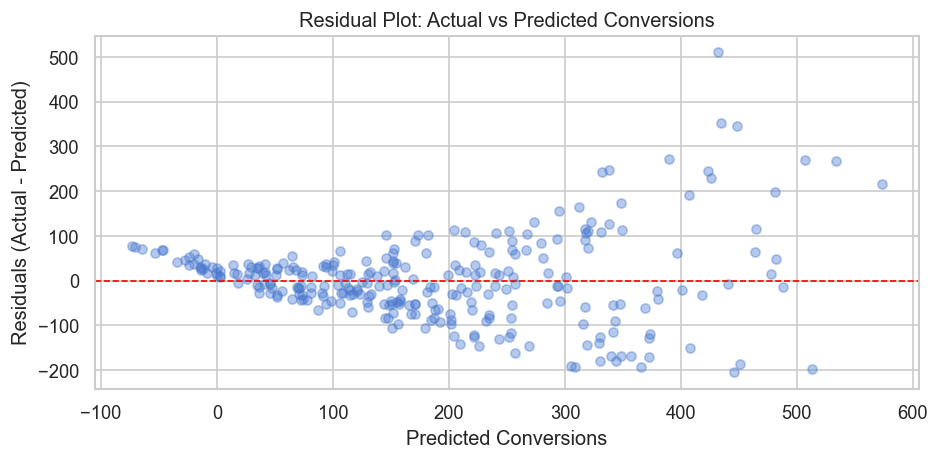

In [37]:
# ============================================
# STEP 4: RESIDUAL PLOT (ACTUAL VS PREDICTED)
# ============================================

residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.4, s=30)
plt.axhline(y=0, color='red', linewidth=1, linestyle='--')
plt.title('Residual Plot: Actual vs Predicted Conversions')
plt.xlabel('Predicted Conversions')
plt.ylabel('Residuals (Actual - Predicted)')
plt.tight_layout()
plt.show()

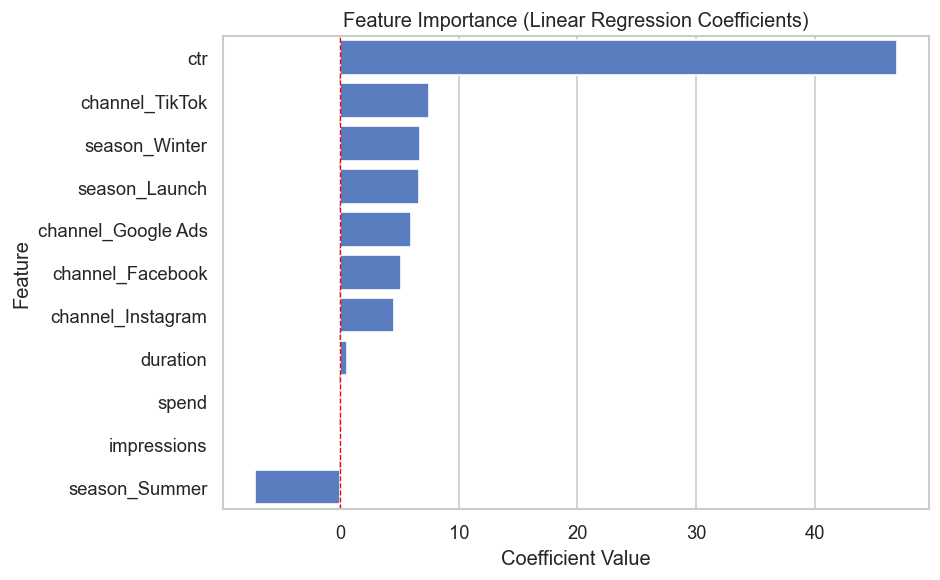

In [38]:
# ============================================
# STEP 5: FEATURE IMPORTANCE
# ============================================

importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
}).sort_values('coefficient',ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='coefficient', y='feature')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(x=0, color='red', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()


# DATA CLEAENING QUALITY REPORT

In [39]:
# ============================================
# STEP 1: BUILD THE REPORT
# ============================================

report= pd.DataFrame([
    {
        'step'       : '1. Header Cleaning',
        'issue'      : 'Inconsistent column names (spaces, mixed case)',
        'rows_fixed' : 12,
        'method'     : 'str.strip().str.lower().str.replace()'
    },
    {
        'step'       : '2. Currency Cleaning',
        'issue'      : 'Spend stored as string with $ symbol',
        'rows_fixed' : df['spend'].notna().sum(),
        'method'     : 'regex strip + pd.to_numeric()'
    },
    {
        'step'       : '3. Categorical Typos',
        'issue'      : 'Misspelled channel names (Facebok, Tik_Tok, etc.)',
        'rows_fixed' : 8,
        'method'     : 'cleanup_map + .replace()'
    },
    {
        'step'       : '4. Boolean Standardization',
        'issue'      : 'Active column had Y/N/Yes/No/True/1/False mixed',
        'rows_fixed' : df['active'].notna().sum(),
        'method'     : 'bool_map + .map() + .astype(bool)'
    },
    {
        'step'       : '5. Date Parsing',
        'issue'      : 'Dates stored as plain text (object dtype)',
        'rows_fixed' : df['start_date'].notna().sum(),
        'method'     : 'pd.to_datetime(errors="coerce")'
    },
    {
        'step'       : '6. Duplicate Column',
        'issue'      : 'Two "clicks" columns existed',
        'rows_fixed' : 2020,
        'method'     : 'df.loc[:, ~df.columns.duplicated()]'
    },
    {
        'step'       : '7. Logical Integrity (clicks)',
        'issue'      : 'Clicks > Impressions (impossible values)',
        'rows_fixed' : int((df['clicks'] > df['impressions']).sum()),
        'method'     : 'Boolean mask + inspection'
    },
    {
        'step'       : '8. Logical Integrity (dates)',
        'issue'      : 'End date before start date (time travel)',
        'rows_fixed' : int((df['end_date'] < df['start_date']).sum()),
        'method'     : 'start_date + pd.Timedelta(days=30)'
    },
    {
        'step'       : '8. Outlier Handling',
        'issue'      : 'Extreme spend values ($500,000) skewing data',
        'rows_fixed' : int((df['spend'] > df['spend'].quantile(0.75) + 3*(df['spend'].quantile(0.75)-df['spend'].quantile(0.25))).sum()),
        'method'     : 'Winsorizing via IQR method'
    },
    {
        'step'       : '9. Feature Extraction',
        'issue'      : 'Season buried inside campaign_name string',
        'rows_fixed' : df['season'].notna().sum(),
        'method'     : 'str.extract() with regex'
    }
])

print(report.to_string(index=False))

                         step                                             issue  rows_fixed                                method
           1. Header Cleaning    Inconsistent column names (spaces, mixed case)          12 str.strip().str.lower().str.replace()
         2. Currency Cleaning              Spend stored as string with $ symbol        2020         regex strip + pd.to_numeric()
         3. Categorical Typos Misspelled channel names (Facebok, Tik_Tok, etc.)           8              cleanup_map + .replace()
   4. Boolean Standardization   Active column had Y/N/Yes/No/True/1/False mixed        2020     bool_map + .map() + .astype(bool)
              5. Date Parsing         Dates stored as plain text (object dtype)        1687       pd.to_datetime(errors="coerce")
          6. Duplicate Column                      Two "clicks" columns existed        2020   df.loc[:, ~df.columns.duplicated()]
7. Logical Integrity (clicks)          Clicks > Impressions (impossible values)           

In [40]:
# ============================================
# STEP 2: SUMMARY STATS
# ============================================

print("=" * 45)
print("       DATA CLEANING SUMMARY REPORT")
print("=" * 45)
print(f"    Original shape    : 2020 rows, 12 columns")
print(f"    Final shape       : {df.shape[0]} rows, {df.shape[1]} columns")
print(f"    Cleaning steps    : {len(report)}")
print(f"    Issues resolved   : {len(report)}")
print(f"    Nulls remaining   : {df.isnull().sum().sum()}")
print(f"    Duplicates        : {df.duplicated().sum()}")
print("=" * 45)

       DATA CLEANING SUMMARY REPORT
    Original shape    : 2020 rows, 12 columns
    Final shape       : 2020 rows, 17 columns
    Cleaning steps    : 10
    Issues resolved   : 10
    Nulls remaining   : 1368
    Duplicates        : 19


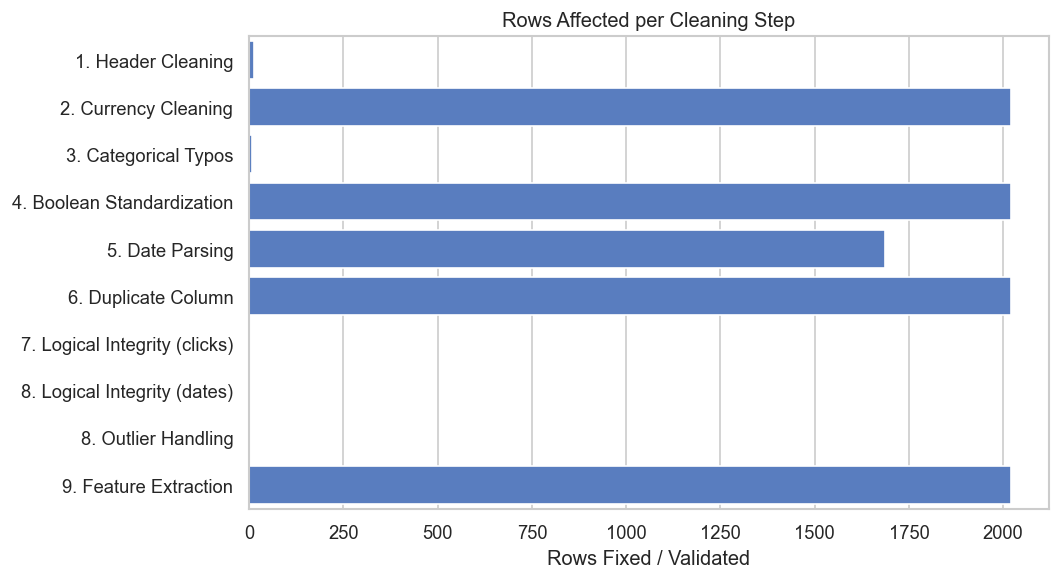

In [41]:
# ============================================
# STEP 3: VISUALIZE THE REPORT
# ============================================

plt.figure(figsize=(9, 5))
sns.barplot(data=report,x='rows_fixed',y='step',orient='h')
plt.title('Rows Affected per Cleaning Step')
plt.xlabel('Rows Fixed / Validated')
plt.ylabel('')
plt.tight_layout()
plt.show()